# Exploring SMARD Electricity Market Data

This notebook explores real German electricity market data from [SMARD](https://www.smard.de/), the official transparency platform for the German electricity market.

## Data Source
- **Day-ahead prices**: Hourly wholesale electricity prices (€/MWh)
- **Grid load**: Total electricity consumption across Germany (MWh)

## Key Finding
SMARD provides **grid-level data** (entire German electricity grid), not household-level data. The load values are in the range of 30,000-80,000 MWh per hour, representing millions of households and industrial consumers combined.

**Conclusion**: This data is useful for understanding market dynamics but not directly applicable for simulating individual household consumption. We use synthetic data instead for the workshop.

## Load and Parse CSV Data

The SMARD CSV files use semicolon as delimiter and comma as thousand separator.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv(
    'Day-ahead_prices_202301020000_202602020000_Hour.csv',
    sep=';',
    encoding='utf-8-sig',
    usecols=['Start date', 'Germany/Luxembourg [€/MWh] Calculated resolutions'],
    na_values=['-'],
    thousands=','
)
prices.columns = ['timestamp', 'price_eur_mwh']
prices['timestamp'] = pd.to_datetime(prices['timestamp'], format='%b %d, %Y %I:%M %p')
prices.head()

,timestamp,price_eur_mwh
0,2023-01-02 00:00:00,57.91
1,2023-01-02 01:00:00,51.67
2,2023-01-02 02:00:00,52.93
3,2023-01-02 03:00:00,44.09
4,2023-01-02 04:00:00,50.08


In [3]:
load = pd.read_csv(
    'Actual_consumption_202301020000_202602020000_Hour.csv',
    sep=';',
    encoding='utf-8-sig',
    usecols=['Start date', 'grid load [MWh] Calculated resolutions'],
    na_values=['-'],
    thousands=','
)
load.columns = ['timestamp', 'load_mwh']
load['timestamp'] = pd.to_datetime(load['timestamp'], format='%b %d, %Y %I:%M %p')
load.head()

,timestamp,load_mwh
0,2023-01-02 00:00:00,36789.75
1,2023-01-02 01:00:00,35423.75
2,2023-01-02 02:00:00,35284.25
3,2023-01-02 03:00:00,36058.50
4,2023-01-02 04:00:00,37796.00


## Merge and Summarize

Combine price and load data into a single DataFrame.

In [4]:
df = prices.merge(load, on='timestamp').set_index('timestamp').sort_index()
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total hours: {len(df)}")
df.describe()

Date range: 2023-01-02 00:00:00 to 2026-02-01 23:00:00
Total hours: 27054


,price_eur_mwh,load_mwh
count,27054.000000,27054.000000
mean,88.348141,53083.424729
std,51.091457,9262.495679
min,-500.000000,30902.750000
25%,66.165000,45474.100000
50%,90.795000,53177.655000
75%,113.547500,59888.437500
max,936.280000,78240.410000


## Visualize Full Dataset

Note the high variability in prices, including occasional negative prices (when renewable generation exceeds demand).

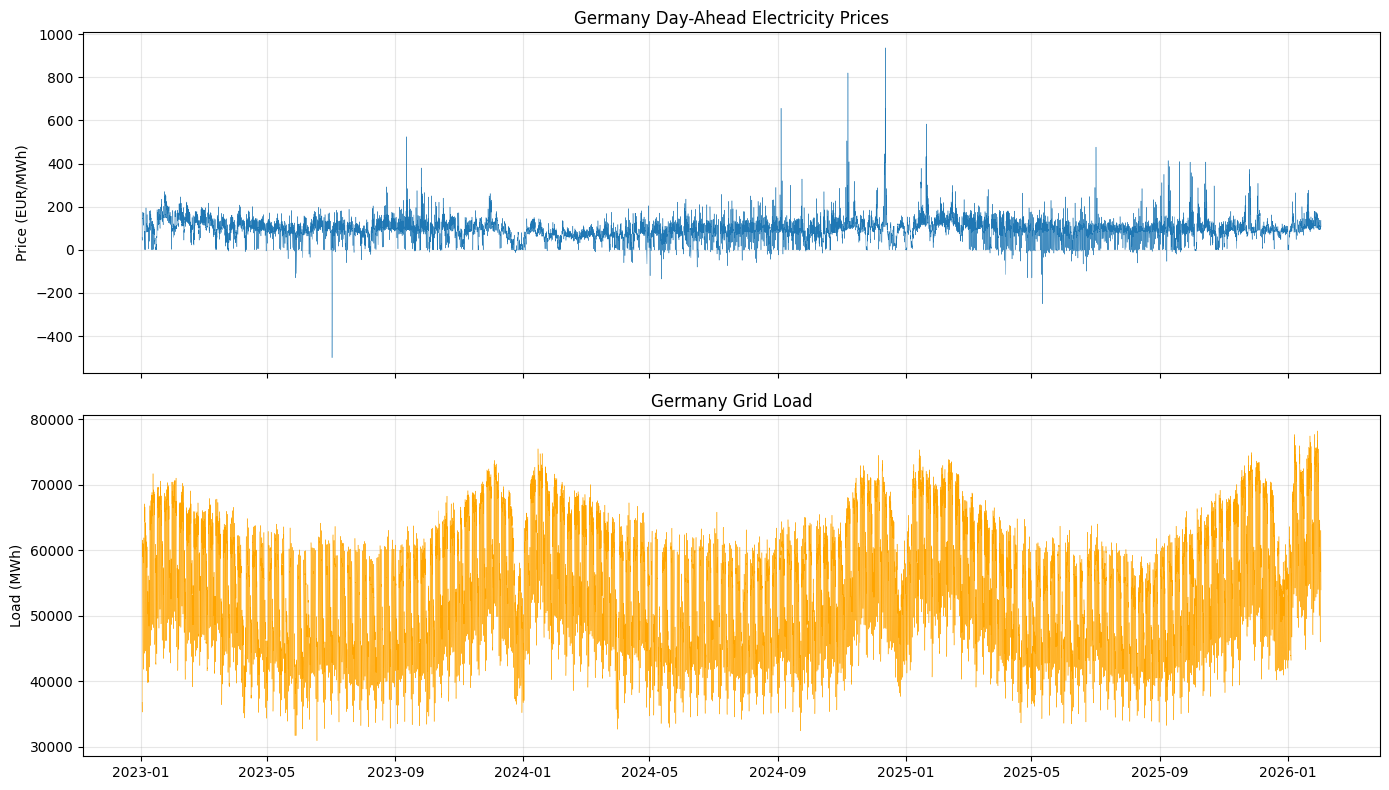

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df.index, df['price_eur_mwh'], linewidth=0.3)
ax1.set_ylabel('Price (EUR/MWh)')
ax1.set_title('Germany Day-Ahead Electricity Prices')
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['load_mwh'], linewidth=0.3, color='orange')
ax2.set_ylabel('Load (MWh)')
ax2.set_title('Germany Grid Load')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Weekly Pattern

Zooming into a single week shows the daily patterns more clearly. Prices tend to peak during morning and evening hours when demand is highest.

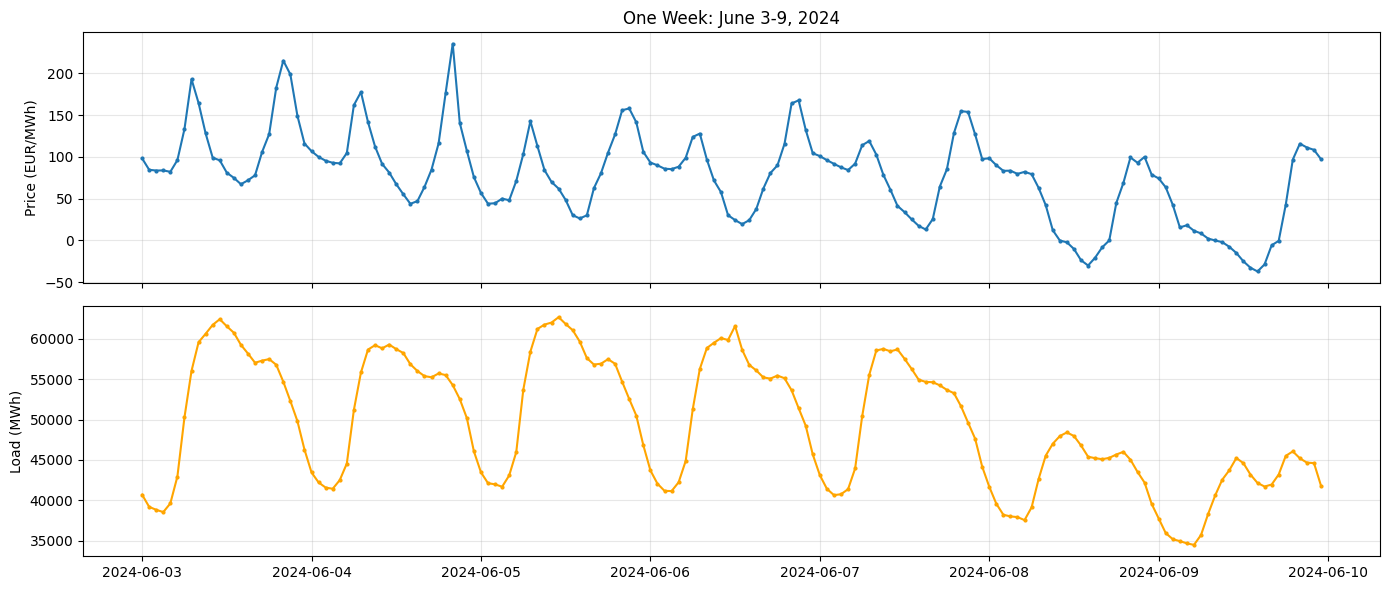

In [6]:
week = df['2024-06-03':'2024-06-09']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(week.index, week['price_eur_mwh'], marker='o', markersize=2)
ax1.set_ylabel('Price (EUR/MWh)')
ax1.set_title('One Week: June 3-9, 2024')
ax1.grid(True, alpha=0.3)

ax2.plot(week.index, week['load_mwh'], marker='o', markersize=2, color='orange')
ax2.set_ylabel('Load (MWh)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()